In [19]:
#inisialisasi
import matplotlib.pyplot as plt
import numpy as np
import math

from qiskit import IBMQ, Aer, transpile, execute
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.providers.ibmq import least_busy

from qiskit.visualization import plot_histogram

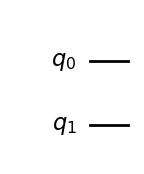

In [20]:
n = 2
gc = QuantumCircuit(n)

gc.draw('mpl')

In [21]:
def initialize_s(qc, qubits):
    #apply Hadamard ke dalem gc
    for q in qubits:
        qc.h(q)
    return qc

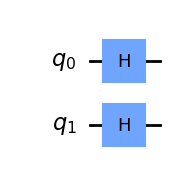

In [22]:
gc = initialize_s(gc, [0,1])
gc.draw('mpl')

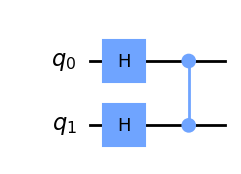

In [23]:
gc.cz(0,1)  #oracle
gc.draw('mpl')

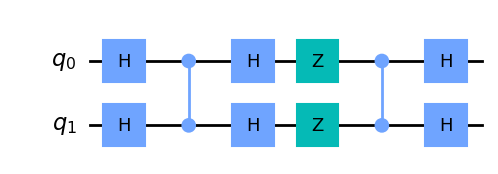

In [24]:
#operator diffusion
gc.h([0,1])
gc.z([0,1])
gc.cz(0,1)
gc.h([0,1])
#gc.barrier()
gc.draw('mpl')

In [25]:
#menjalankan simulasi
sv_sim = Aer.get_backend('statevector_simulator')
result = execute(gc, sv_sim).result()
statevec = result.get_statevector()

from qiskit.visualization import array_to_latex

array_to_latex(statevec, prefix="|\\psi\\rangle =")

<IPython.core.display.Latex object>

AttributeError: 'YTick' object has no attribute 'label'

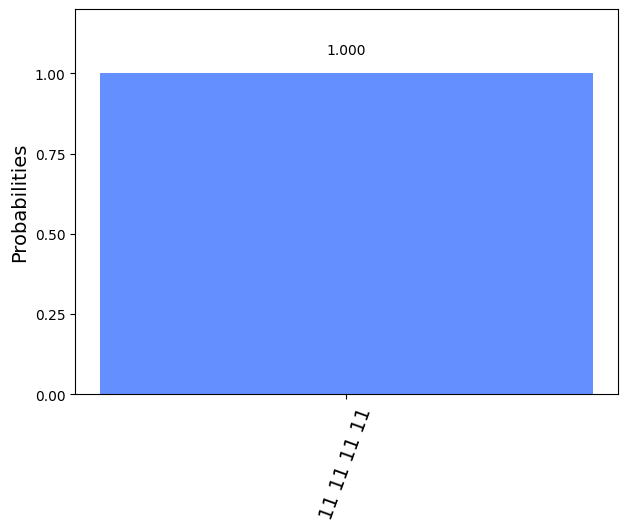

In [27]:
gc.measure_all()
qasm_sim = Aer.get_backend('qasm_simulator')
result = execute(gc, qasm_sim).result()
counts = result.get_counts()
gc.measure_all()
qasm_sim = Aer.get_backend('qasm_simulator')
result = execute(gc, qasm_sim).result()
counts = result.get_counts()
plot_histogram(counts)

In [ ]:
provider = IBMQ.load_account()
provider = IBMQ.get_provider("ibm-q")

IBMQAccountCredentialsNotFound: 'No IBM Quantum Experience credentials found.'